In [ ]:
# !pip install econml

Note: you may need to restart the kernel to use updated packages.


In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# IHDP: ForestRiesz

## Library Imports

In [4]:
from pathlib import Path
import os
import glob
from joblib import dump, load
import pandas as pd
import scipy
import scipy.stats
import scipy.special
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from utils.forestriesz import ForestRieszATE
from utils.ihdp_data import *

## Moment Definition

In [5]:
def moment_fn(x, test_fn): # Returns the moment for the ATE example, for each sample in x
    t1 = np.hstack([np.ones((x.shape[0], 1)), x[:, 1:]])
    t0 = np.hstack([np.zeros((x.shape[0], 1)), x[:, 1:]])
    return test_fn(t1) - test_fn(t0)

## MAE Experiment

In [6]:
data_base_dir = "./data/IHDP/sim_data"
simulation_files = sorted(glob.glob("{}/*.csv".format(data_base_dir)))

In [7]:
nsims = 1000
np.random.seed(123)
sim_ids = np.random.choice(len(simulation_files), nsims, replace=False)
methods = ['dr', 'direct', 'ips', 'plugin']

true_ATEs = []
results = []

for it, sim in enumerate(sim_ids):
    simulation_file = simulation_files[sim]
    x = load_and_format_covariates(simulation_file, delimiter=' ')
    t, y, y_cf, mu_0, mu_1 = load_other_stuff(simulation_file, delimiter=' ')
    X = np.c_[t, x]
    true_ATE = np.mean(mu_1 - mu_0)
    true_ATEs.append(true_ATE)

    y_scaler = StandardScaler(with_mean=True).fit(y)
    y = y_scaler.transform(y)
    est = ForestRieszATE(criterion='het', n_estimators=1000, min_samples_leaf=2,
                         min_var_fraction_leaf=0.001, min_var_leaf_on_val=True,
                         min_impurity_decrease = 0.01, max_samples=.8, max_depth=None,
                         warm_start=False, inference=False, subforest_size=1,
                         honest=True, verbose=0, n_jobs=-1, random_state=123)
    est.fit(X[:, 1:], X[:, [0]], y.reshape(-1, 1))
    
    params = tuple(x * y_scaler.scale_[0] for method in methods
                   for x in est.predict_ate(X, y, method = method)) + (true_ATE, )
                        
    results.append(params)

res = tuple(np.array(x) for x in zip(*results))
truth = res[-1:]
res_dict = {}
for it, method in enumerate(methods):
    point, lb, ub = res[it * 3: (it + 1)*3]
    res_dict[method] = {'point': point, 'lb': lb, 'ub': ub,
                        'MAE': np.mean(np.abs(point - truth)),
                        'std. err.': np.std(np.abs(point - truth)) / np.sqrt(nsims),
                        }
    print("{} : MAE = {:.3f} +/- {:.3f}".format(method, res_dict[method]['MAE'], res_dict[method]['std. err.']))

dr : MAE = 0.126 +/- 0.004
direct : MAE = 0.197 +/- 0.007
ips : MAE = 0.670 +/- 0.004
plugin : MAE = 0.390 +/- 0.024


In [8]:
path = './results/IHDP/ForestRiesz/MAE'

if not os.path.exists(path):
    os.makedirs(path)
            
dump(res_dict, path + '/IHDP_MAE_RF.joblib')

['./results/IHDP/ForestRiesz/MAE/IHDP_MAE_RF.joblib']

### Table

In [9]:
path = './results/IHDP/ForestRiesz/MAE'

if not os.path.exists(path):
    os.makedirs(path)

methods_str = ["DR", "Direct", "IPS", "\\midrule \n" +
               "\\multicolumn{2}{l}{\\textbf{Benchmark:}} \\\\ \n RF Plug-in"] 

with open(path + '/IHDP_MAE_RF.tex', "w") as f:
    f.write("\\begin{tabular}{lc} \n" +
            "\\toprule \n" +
            "& MAE $\\pm$ std. err. \\\\ \n" +
            "\\midrule \n" + 
            "\\multicolumn{2}{l}{\\textbf{Auto-DML:}} \\\\ \n")
    
    for i, method in enumerate(methods):
        f.write(" & ".join([methods_str[i], "{:.3f} $\\pm$ {:.3f}".format(res_dict[method]['MAE'], 
                                                                          res_dict[method]['std. err.'])]) + " \\\\ \n")

    f.write("\\bottomrule \n \\end{tabular}")

## Coverage Experiment

In [10]:
data_base_dir = "./data/IHDP/sim_data_redraw_T"
simulation_files = sorted(glob.glob("{}/*.csv".format(data_base_dir)))

In [11]:
def rmse_fn(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true)**2))

nsims = 100
np.random.seed(123)
sim_ids = np.random.choice(len(simulation_files), nsims, replace=False)
methods = ['dr', 'direct', 'ips']

true_ATEs = []
results = []

sim_ids = np.random.choice(len(simulation_files), nsims, replace=False)
for it, sim in enumerate(sim_ids):
    simulation_file = simulation_files[sim]
    x = load_and_format_covariates(simulation_file, delimiter=' ')
    t, y, y_cf, mu_0, mu_1 = load_other_stuff(simulation_file, delimiter=' ')
    X = np.c_[t, x]
    true_ATE = np.mean(mu_1 - mu_0)
    true_ATEs.append(true_ATE)

    y_scaler = StandardScaler(with_mean=True).fit(y)
    y = y_scaler.transform(y)
    est = ForestRieszATE(criterion='het', n_estimators=100, min_samples_leaf=2,
                         min_var_fraction_leaf=0.001, min_var_leaf_on_val=True,
                         min_impurity_decrease = 0.01, max_samples=.8, max_depth=None,
                         warm_start=False, inference=False, subforest_size=1,
                         honest=True, verbose=0, n_jobs=-1, random_state=123)
    est.fit(X[:, 1:], X[:, [0]], y.reshape(-1, 1))

                        
    params = tuple(x * y_scaler.scale_[0] for method in methods
                   for x in est.predict_ate(X, y, method = method)) + (true_ATE, )
                        
    results.append(params)
                        
res = tuple(np.array(x) for x in zip(*results))
truth = res[-1:]
res_dict = {}
for it, method in enumerate(methods):
    point, lb, ub = res[it * 3: (it + 1)*3]
    res_dict[method] = {'point': point, 'lb': lb, 'ub': ub,
                        'cov': np.mean(np.logical_and(truth >= lb, truth <= ub)),
                        'bias': np.mean(point - truth),
                        'rmse': rmse_fn(point, truth)
                        }
    print("{} : bias = {:.3f}, rmse = {:.3f}, cov = {:.3f}".format(method, res_dict[method]['bias'], res_dict[method]['rmse'], res_dict[method]['cov']))

dr : bias = -0.005, rmse = 0.153, cov = 0.960
direct : bias = 0.057, rmse = 0.219, cov = 0.380
ips : bias = -0.750, rmse = 0.765, cov = 0.240


In [12]:
path = './results/IHDP/ForestRiesz/coverage'

if not os.path.exists(path):
    os.makedirs(path)
    
dump(res_dict, path + '/IHDP_coverage_RF.joblib')

['./results/IHDP/ForestRiesz/coverage/IHDP_coverage_RF.joblib']

### Histogram

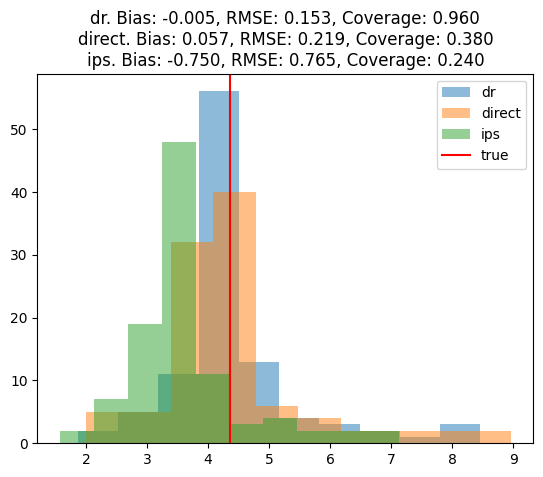

In [13]:
path = './results/IHDP/ForestRiesz/coverage'

if not os.path.exists(path):
    os.makedirs(path)
    
method_strs = ["{}. Bias: {:.3f}, RMSE: {:.3f}, Coverage: {:.3f}".format(method, d['bias'], d['rmse'], d['cov'])
               for method, d in res_dict.items()]
plt.title("\n".join(method_strs))
for method, d in res_dict.items():
    plt.hist(np.array(d['point']), alpha=.5, label=method)
plt.axvline(x = np.mean(truth), label='true', color='red')
plt.legend()
plt.savefig(path + '/IHDP_coverage_RF.pdf', bbox_inches='tight')
plt.show()